<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/Tarefa_4_Modelagem_Preditiva_com_Algoritmos_Supervisionados_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tarefa Individual – Modelagem Preditiva com Algoritmos Supervisionados
Objetivo
Desenvolver um projeto de classificação utilizando uma das bases de dados disponíveis no portal do aluno. O aluno deverá aplicar de um a dois algoritmos supervisionados entre os seguintes:

Regressão Logística

Naive Bayes

Redes Neurais

O foco é construir modelos preditivos, avaliar seu desempenho e interpretar os resultados com base nas variáveis disponíveis.

# Aluno
Fabiano Antunes

## Objetivo

Desenvolver e avaliar modelos de classificação supervisionada (Naive Bayes e duas
implementações de Redes Neurais) para prever o risco de crédito ('Alto Risco'
ou 'Baixo Risco') de clientes, com base em suas características financeiras
e demográficas.


# Etapa 1: Preparação dos Dados

Inspecionar, limpar e transformar em um formato que os algoritmos de Machine Learning possam entender.

## 1.1 Análise Exploratória (EDA) Básica

Carregar os dados e "interagir" com eles. Para responder perguntas como:
* Quais são as colunas? (Features)
* Quais os tipos de dados? (Numéricos, Categóricos, etc.)
* Existem dados faltantes (nulos)?
* Como os dados numéricos estão distribuídos? (Média, mediana, valores mínimos/máximos)
* Como a nossa variável-alvo (`risco`) está distribuída? (Está balanceada?)

Comandos `.head()`, `.info()`, `.describe()` e `.value_counts()`.

## 1.2 Tratamento de Dados Faltantes e Variáveis Categóricas

### Tratamento de Dados Faltantes
A partir da análise do `.info()`, verificamos se há colunas com valores "non-null" menores que o total de entradas.
* **No nosso caso (dados_risco_credito.csv):** O dataset está completo e **não possui dados faltantes**.
* **Se houvesse:** Teríamos que tomar uma decisão:
    * Remover as linhas com dados faltantes (`.dropna()`).
    * Preencher os valores faltantes (`.fillna()`) com a média, mediana (para números) ou a moda (para categorias).

### Tratamento de Variáveis Categóricas
Modelos de Machine Learning (como Regressão Logística, Naive Bayes e Redes Neurais) não entendem texto (ex: 'Bom', 'Ruim', 'Própria', 'Alugada'). Precisamos convertê-los em números.

1.  **Variável-Alvo (y):** Para a coluna `risco`, usaremos o **`LabelEncoder`**. Ele transforma 'Alto Risco' em 0 e 'Baixo Risco' em 1 (ou vice-versa).
2.  **Variáveis de Features (X):** Para colunas como `historico_credito` ou `estado_civil`, não podemos usar o `LabelEncoder` pois o modelo aprenderia uma ordem que não existe (ex: 'Casado' = 2, 'Solteiro' = 1). Usamos o **`OneHotEncoder`**, que cria novas colunas binárias (0 ou 1) para cada categoria (ex: `estado_civil_Casado`, `estado_civil_Solteiro`).

## 1.3 Normalização ou Padronização

### Por que é necessário?
Algoritmos são sensíveis à escala das features. No nosso dataset, a `idade` varia de 18 a 70, enquanto a `renda_mensal` pode ir de 1000 a 7000. Isso pode fazer com que o modelo dê um peso indevido à `renda_mensal` apenas por ela ter números maiores.

* **Padronização (StandardScaler):** Transforma os dados para que tenham média 0 e desvio padrão 1. É a técnica mais comum e essencial para Redes Neurais, Regressão Logística, SVMs, etc.

Para aplicar a Padronização (nas colunas numéricas) e o OneHotEncoding (nas colunas categóricas) de forma correta e organizada, usamos um `ColumnTransformer` e um `Pipeline`. Isso também previne *data leakage* (vazamento de dados).

# Etapa 2: Modelagem (Preparação)

Com o plano de pré-processamento definido, a última etapa antes de treinar os modelos é:

1.  **Separar os dados:** Dividimos o dataset em **Features (X)** e **Alvo (y)**.
2.  **Dividir em Treino e Teste:** Usamos `train_test_split` para separar os dados em um conjunto de treino (ex: 80% dos dados) e um conjunto de teste (ex: 20%).
    * O modelo *aprende* com os dados de treino.
    * O modelo é *avaliado* nos dados de teste (dados que ele nunca viu).
    * Usamos `stratify=y` para garantir que a proporção de 'Alto Risco' e 'Baixo Risco' seja a mesma nos conjuntos de treino e teste.
3.  **Aplicar o Pré-processamento:**
    * Ajustamos (`.fit_transform()`) o `preprocessor` (StandardScaler + OneHotEncoder) **APENAS** nos dados de treino.
    * Apenas transformamos (`.transform()`) os dados de teste com o processador já ajustado.

--- 1.1: Análise Exploratória (EDA) Básica ---
Dataset 'dados_risco_credito.csv' carregado.

--- df.head() ---
   idade  renda_mensal historico_credito  tempo_emprego tipo_residencia  \
0     56       1090.33              Ruim             14         Própria   
1     69       3805.20               Bom              3         Própria   
2     46       2365.47               Bom             11         Própria   
3     32       1366.62           Regular              5         Alugada   
4     60       2530.14              Ruim             18      Financiada   

  estado_civil  numero_dependentes  valor_solicitado finalidade_credito  \
0     Solteiro                   1          26978.03            Negócio   
1       Casado                   0          24718.47             Imóvel   
2       Casado                   3          16528.29             Imóvel   
3   Divorciado                   0           9989.08           Educação   
4     Solteiro                   3          15442.09           

/tmp/ipython-input-3987913820.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risco', data=df, palette='pastel')



Gráfico 'eda_distribuicao_risco.png' salvo.


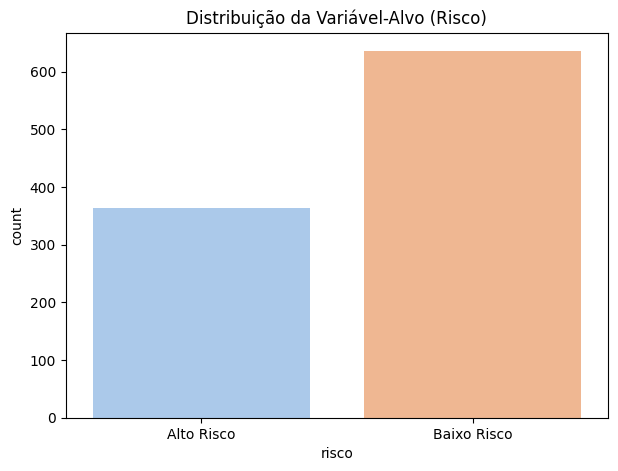


--- 1.2: Tratamento de Variáveis (Definição) ---
Análise do .info() confirma: Não há dados faltantes.

Variável-alvo 'risco' codificada.
Classes originais: ['Alto Risco' 'Baixo Risco']
Mapeamento: Alto Risco -> 0, Baixo Risco -> 1

--- 1.3: Definição do Pipeline de Pré-processamento ---
Colunas Numéricas (5): ['idade', 'renda_mensal', 'tempo_emprego', 'numero_dependentes', 'valor_solicitado']
Colunas Categóricas (4): ['historico_credito', 'tipo_residencia', 'estado_civil', 'finalidade_credito']

Pipeline de pré-processamento (preprocessor) criado com sucesso.

--- 2: Modelagem (Preparação e Separação Treino/Teste) ---
Dados divididos: 800 para treino, 200 para teste.

Aplicando pré-processamento (fit_transform nos dados de treino)...
Aplicando pré-processamento (transform nos dados de teste)...

--- Pré-processamento Concluído ---
Formato dos dados de treino processados: (800, 18)
Formato dos dados de teste processados: (200, 18)
Tipo de dados de saída: <class 'numpy.ndarray'>

Os dad

In [1]:
#  Importações bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ETAPA 1.1: ANÁLISE EXPLORATÓRIA (EDA) BÁSICA

print("--- 1.1: Análise Exploratória (EDA) Básica ---")

# Carregar o dataset
try:
    df = pd.read_csv('dados_risco_credito.csv')
    print("Dataset 'dados_risco_credito.csv' carregado.\n")
except FileNotFoundError:
    print("ERRO: Arquivo 'dados_risco_credito.csv' não encontrado.")
    print("Por favor, faça o upload do arquivo no ambiente.")
    # Encerra a execução se o arquivo não for encontrado
    exit()

# 1. Inspecionar as primeiras linhas
print("--- df.head() ---")
print(df.head())

# 2. Verificar tipos de dados e dados faltantes
print("\n--- df.info() ---")
df.info()

# 3. Análise estatística das colunas numéricas
print("\n--- df.describe() ---")
print(df.describe())

# 4. Verificar balanceamento da variável-alvo 'risco'
print("\n--- Distribuição da Variável-Alvo 'risco' ---")
print(df['risco'].value_counts(normalize=True))

# Plotar a distribuição da variável-alvo
plt.figure(figsize=(7, 5))
sns.countplot(x='risco', data=df, palette='pastel')
plt.title('Distribuição da Variável-Alvo (Risco)')
plt.savefig('eda_distribuicao_risco.png')
print("\nGráfico 'eda_distribuicao_risco.png' salvo.")
plt.show()
plt.close()


# ETAPA 1.2: TRATAMENTO DE VARIÁVEIS (Definição)

print("\n--- 1.2: Tratamento de Variáveis (Definição) ---")

# 1. Tratamento de Dados Faltantes
# Com base no .info(), vemos que não há dados nulos (1000 non-null em 1000 entradas).
# Se houvesse, aplicaríamos df.fillna() ou df.dropna() aqui.
print("Análise do .info() confirma: Não há dados faltantes.")

# 2. Definição de Features (X) e Alvo (y)
X = df.drop('risco', axis=1)
y = df['risco']

# 3. Tratamento da Variável-Alvo (y) -> LabelEncoder
le = LabelEncoder()
# fit_transform encontra as classes e as transforma em números
y_encoded = le.fit_transform(y)
print(f"\nVariável-alvo 'risco' codificada.")
print(f"Classes originais: {le.classes_}")
print(f"Mapeamento: {le.classes_[0]} -> 0, {le.classes_[1]} -> 1")



# ETAPA 1.3: NORMALIZAÇÃO E PADRONIZAÇÃO (Definição do Pipeline)

print("\n--- 1.3: Definição do Pipeline de Pré-processamento ---")

# 1. Identificar colunas numéricas e categóricas
colunas_numericas = X.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = X.select_dtypes(include=['object']).columns

print(f"Colunas Numéricas ({len(colunas_numericas)}): {list(colunas_numericas)}")
print(f"Colunas Categóricas ({len(colunas_categoricas)}): {list(colunas_categoricas)}")

# 2. Criar o transformador para colunas numéricas (Padronização)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 3. Criar o transformador para colunas categóricas (One-Hot Encoding)
# drop='first' evita a multicolinearidade (dummy variable trap)
# handle_unknown='ignore' faz com que o modelo ignore categorias
# que ele não viu no treino (evita erros em produção)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 4. Combinar os transformadores em um único "Pré-processador"
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, colunas_numericas),
        ('cat', categorical_transformer, colunas_categoricas)
    ],
    remainder='passthrough' # Mantém colunas não especificadas (se houver)
)

print("\nPipeline de pré-processamento (preprocessor) criado com sucesso.")


# ETAPA 2: MODELAGEM (Preparação e Separação Treino/Teste)

print("\n--- 2: Modelagem (Preparação e Separação Treino/Teste) ---")

# 1. Dividir os dados em Treino (80%) e Teste (20%)
# Usamos 'y_encoded' para o 'stratify'
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,    # 20% para teste
    random_state=42,  # Para reprodutibilidade
    stratify=y_encoded # Manter a proporção das classes
)

print(f"Dados divididos: {len(y_train)} para treino, {len(y_test)} para teste.")

# 2. Aplicar o Pré-processamento (A GRANDE ETAPA)
print("\nAplicando pré-processamento (fit_transform nos dados de treino)...")
# Ajustamos e transformamos os dados de TREINO
X_train_processed = preprocessor.fit_transform(X_train)

print("Aplicando pré-processamento (transform nos dados de teste)...")
# Apenas transformamos os dados de TESTE (usando o ajuste do treino)
X_test_processed = preprocessor.transform(X_test)

# 3. Verificar o resultado
print("\n--- Pré-processamento Concluído ---")
print(f"Formato dos dados de treino processados: {X_train_processed.shape}")
print(f"Formato dos dados de teste processados: {X_test_processed.shape}")
print(f"Tipo de dados de saída: {type(X_train_processed)}")
print("\nOs dados 'X_train_processed', 'X_test_processed', 'y_train', 'y_test' estão prontos para a modelagem.")

--- Célula 2: Importando Bibliotecas ---
Bibliotecas importadas com sucesso.

--- Célula 3: Etapa 1.1 - Carga e Inspeção Inicial ---
Dataset 'dados_risco_credito.csv' carregado com sucesso.

--- Visualização das primeiras linhas (head) ---
   idade  renda_mensal historico_credito  tempo_emprego tipo_residencia  \
0     56       1090.33              Ruim             14         Própria   
1     69       3805.20               Bom              3         Própria   
2     46       2365.47               Bom             11         Própria   
3     32       1366.62           Regular              5         Alugada   
4     60       2530.14              Ruim             18      Financiada   

  estado_civil  numero_dependentes  valor_solicitado finalidade_credito  \
0     Solteiro                   1          26978.03            Negócio   
1       Casado                   0          24718.47             Imóvel   
2       Casado                   3          16528.29             Imóvel   
3   Divor

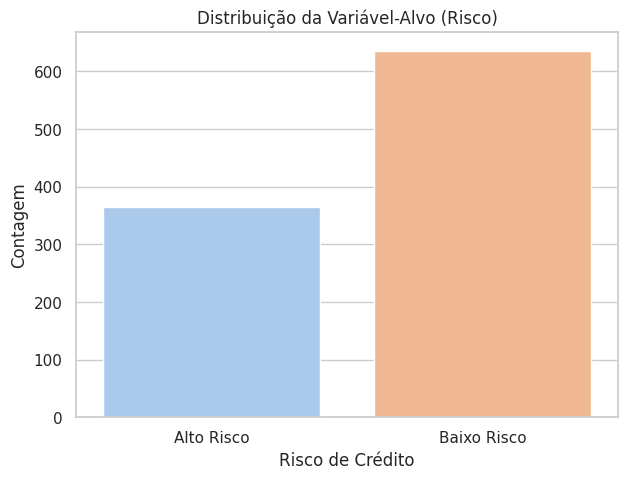


Colunas Numéricas: ['idade', 'renda_mensal', 'tempo_emprego', 'numero_dependentes', 'valor_solicitado']
Salvo: 'grafico_2_histogramas_numericos.png'


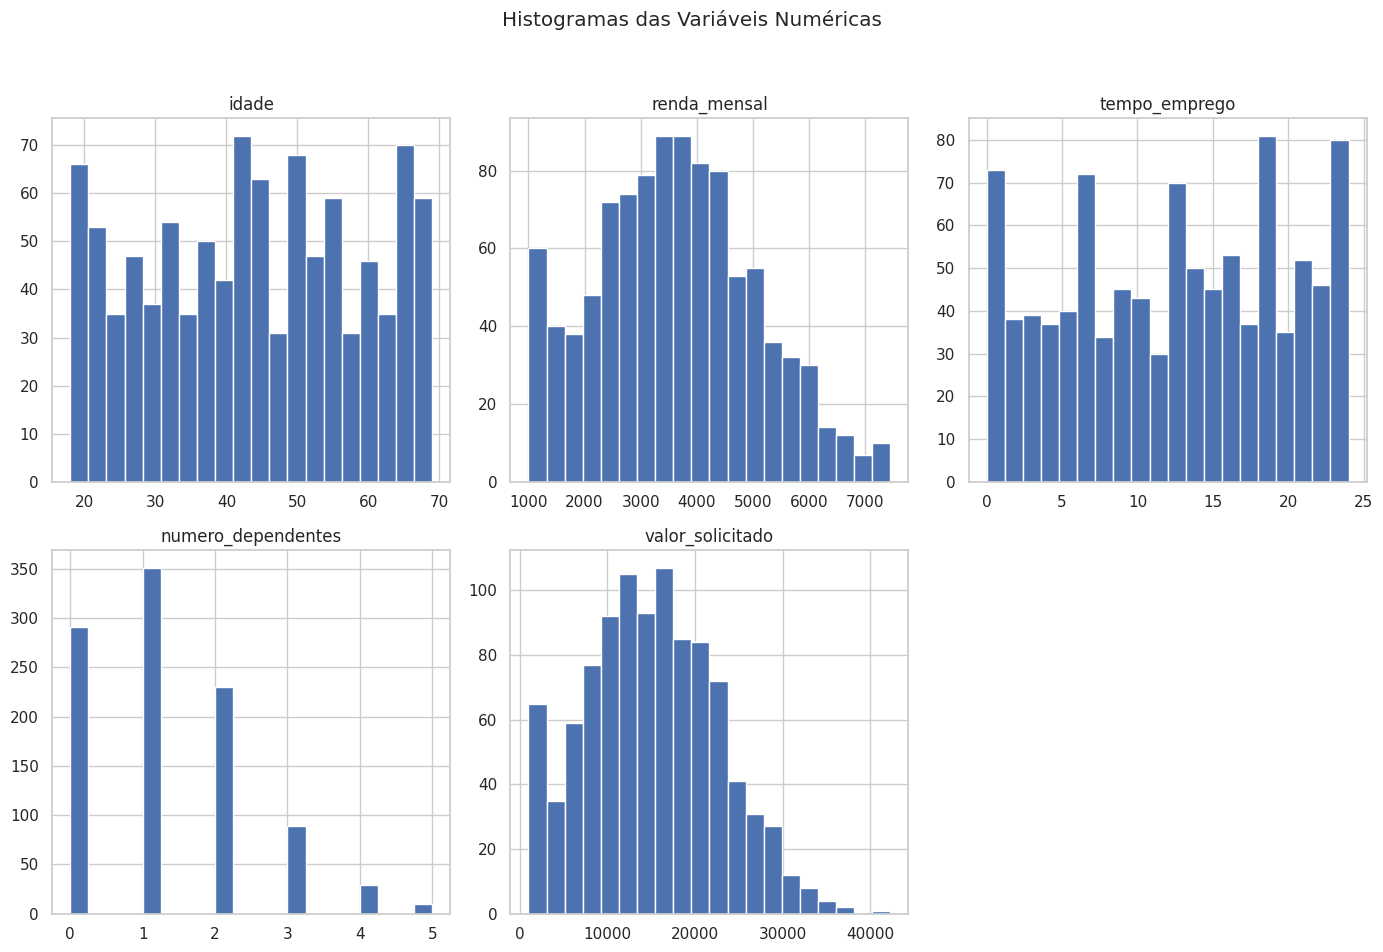


Gerando boxplots Numéricos vs. Risco...
Salvo: 'grafico_3_boxplots_numericos.png'


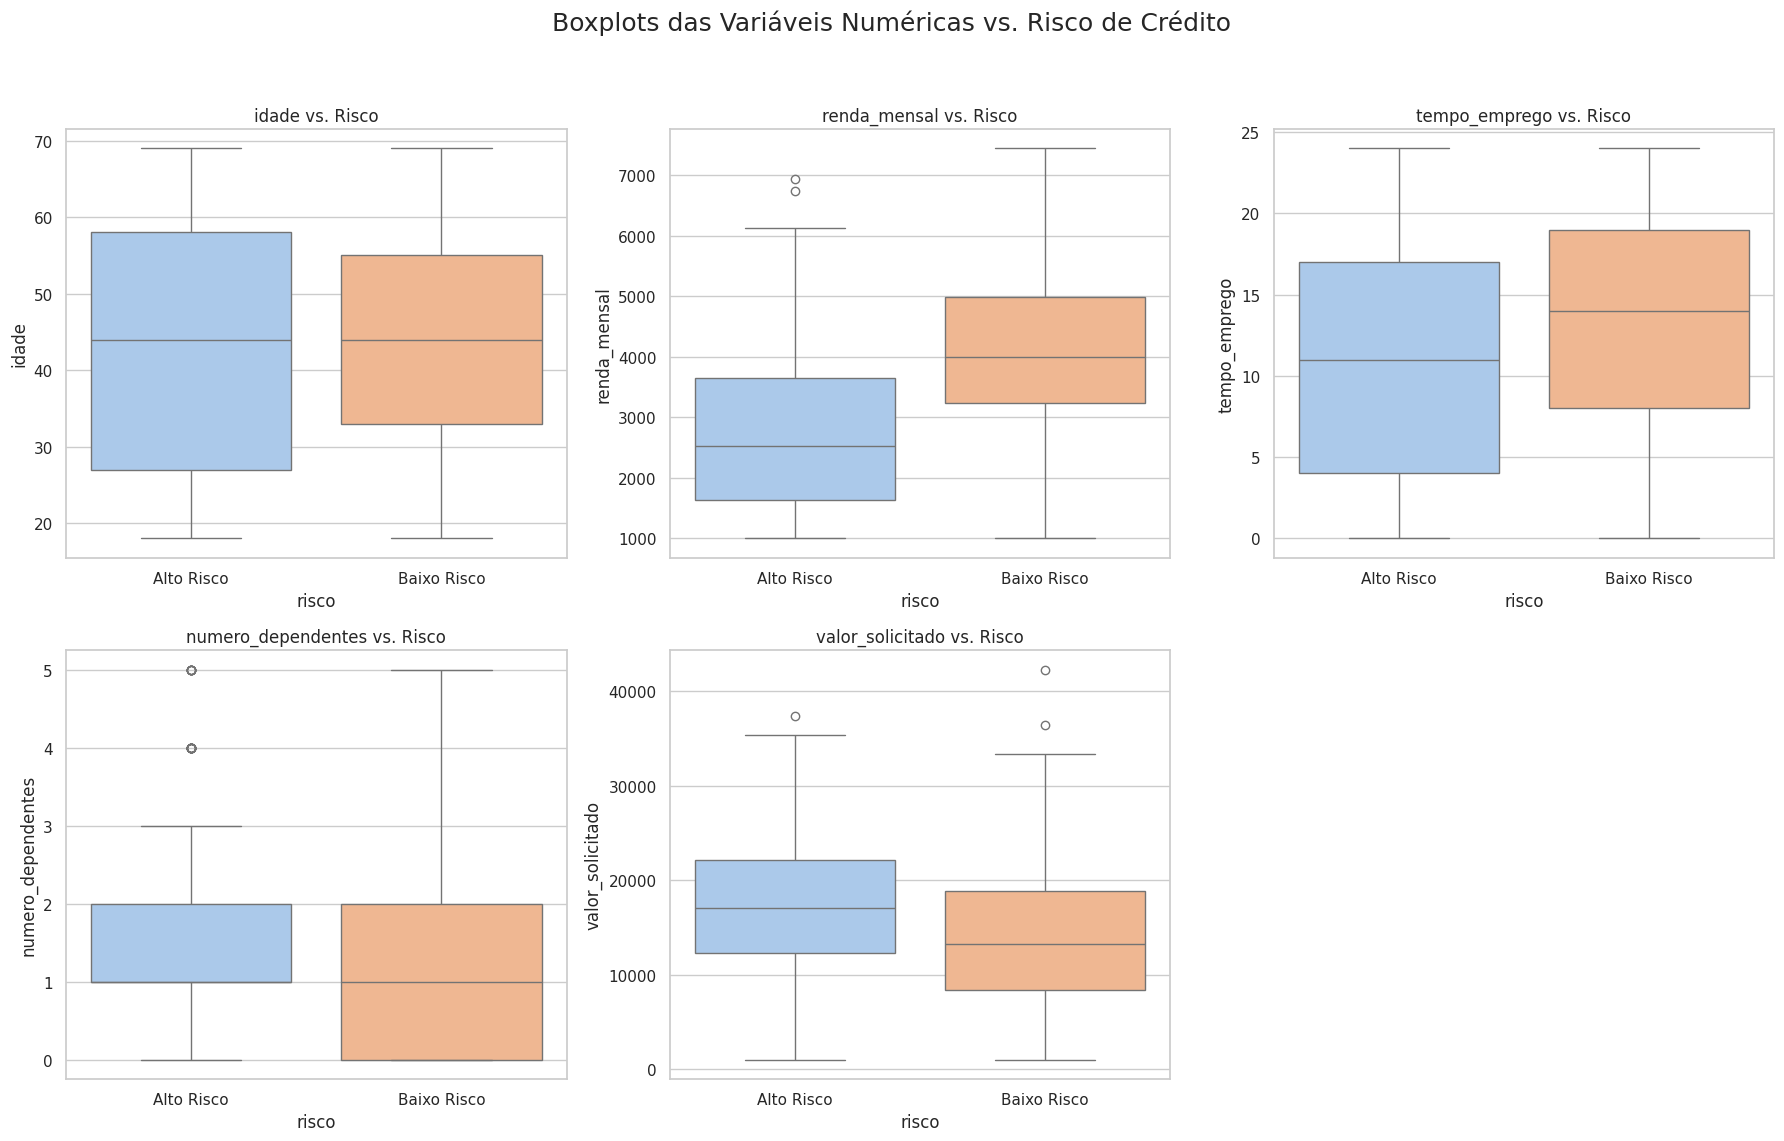


Colunas Categóricas: ['historico_credito', 'tipo_residencia', 'estado_civil', 'finalidade_credito']
Salvo: 'grafico_4_countplots_categoricos.png'


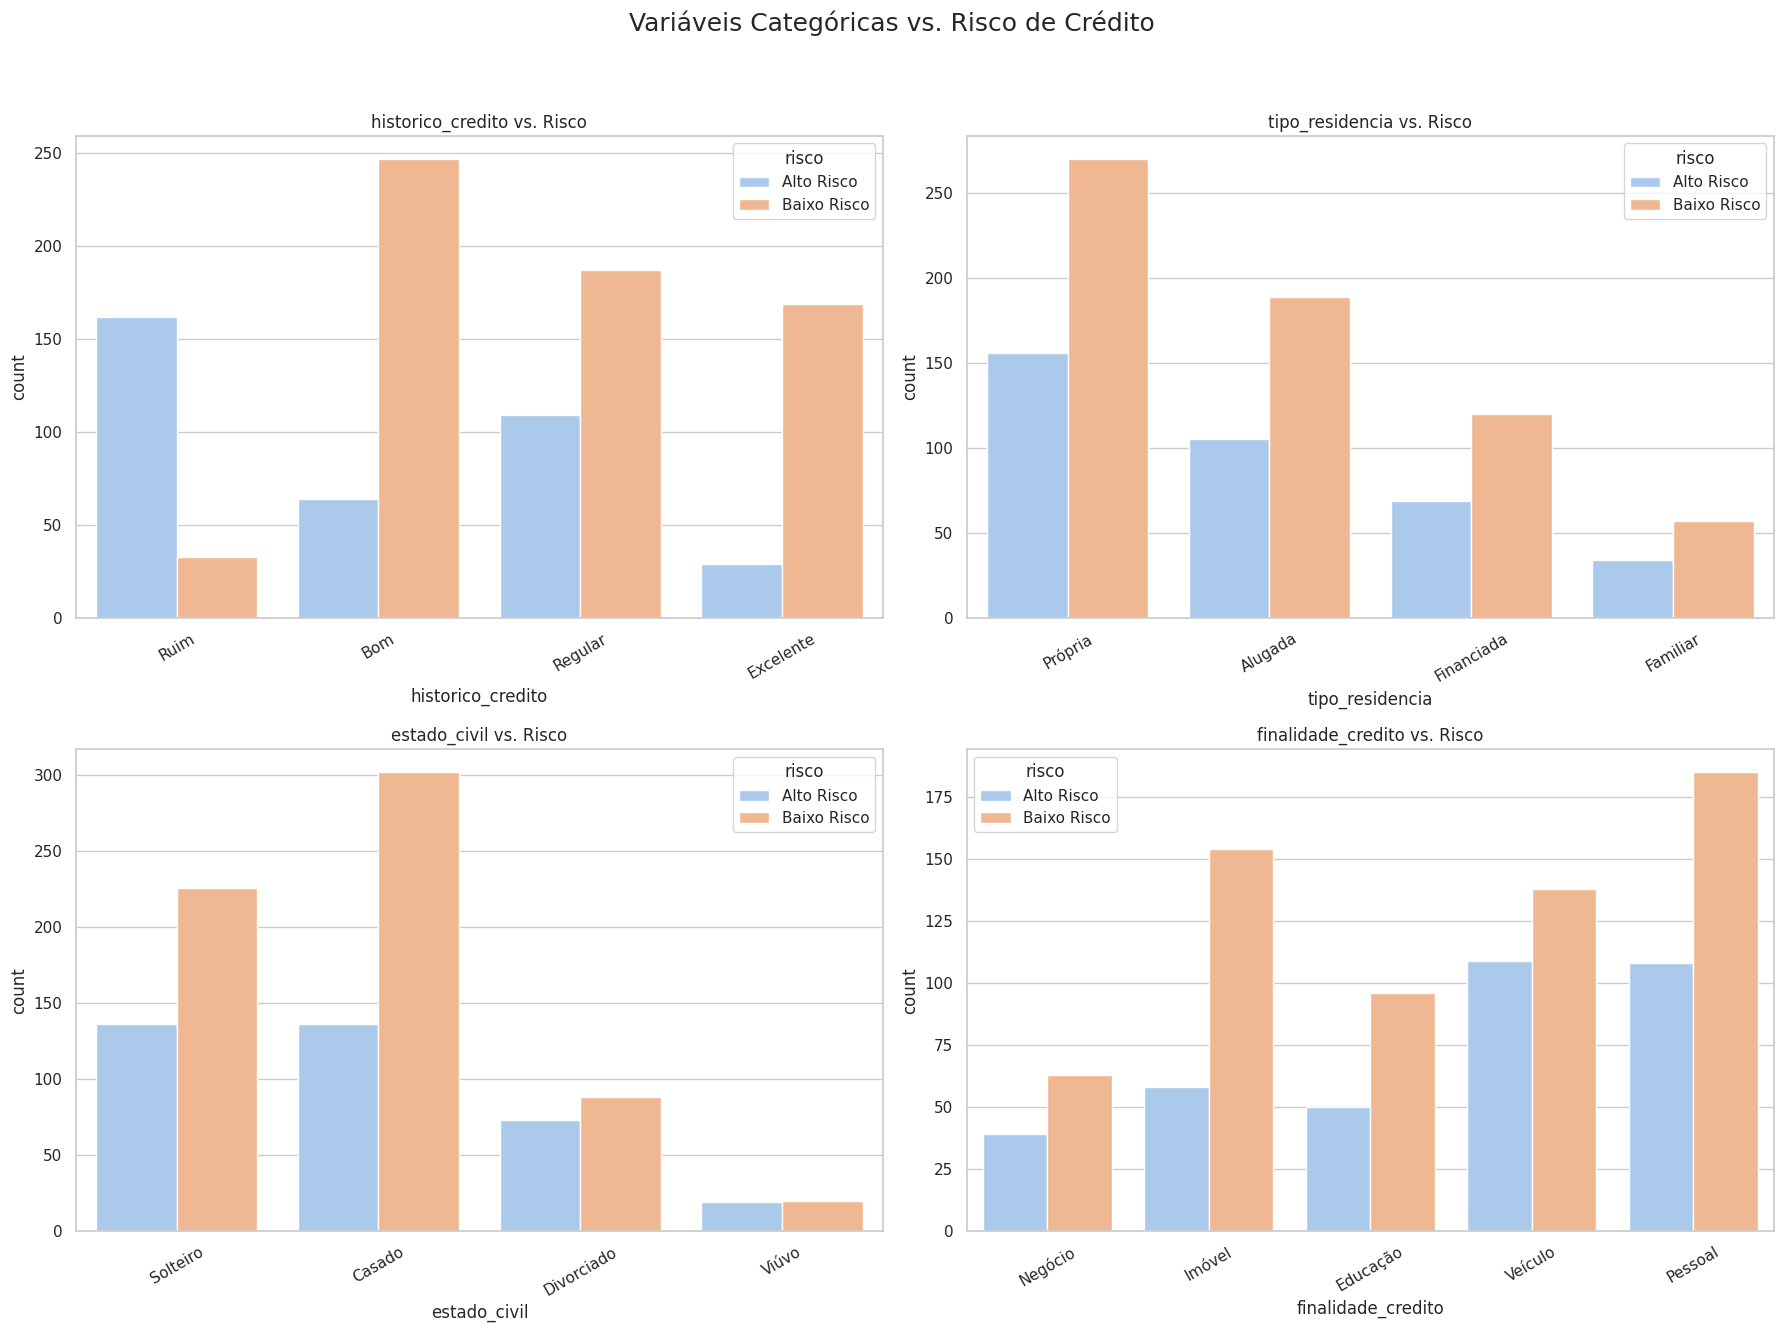


Análise Exploratória Gráfica concluída.


--- Célula 5: Etapa 1.3 - Pré-processamento e Separação ---
Classes da variável 'risco' mapeadas: {0: 'Alto Risco', 1: 'Baixo Risco'}

Tamanho do conjunto de Treino: 800 amostras
Tamanho do conjunto de Teste: 200 amostras

Aplicando pré-processamento (fit/transform)...
Formato dos dados de treino processados (features): (800, 18)
Formato dos dados de teste processados (features): (200, 18)

Pré-processamento concluído.


--- Célula 6: Etapa 2 - Modelagem (Justificativa) ---


--- Célula 7: Etapa 2.1 - Treinamento (Modelo 1: Gaussian Naive Bayes) ---
Treinando Gaussian Naive Bayes...
Tempo de treino: 0.0027 segundos

--- Resultados (Gaussian Naive Bayes) ---
Acurácia (Naive Bayes): 0.8300

Relatório de Classificação (Naive Bayes):
              precision    recall  f1-score   support

  Alto Risco       0.79      0.73      0.76        73
 Baixo Risco       0.85      0.89      0.87       127

    accuracy                           0.83       200

Model: "RedeNeural_TensorFlow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,001 (27.35 KB)

 Trainable params: 7,001 (27.35 KB)

 Non-trainable params: 0 (0.00 B)


Treinando Rede Neural (TensorFlow/Keras)...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5991 - loss: 0.6642 - val_accuracy: 0.8000 - val_loss: 0.5412
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7591 - loss: 0.5285 - val_accuracy: 0.8375 - val_loss: 0.4367
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8367 - loss: 0.4110 - val_accuracy: 0.8750 - val_loss: 0.3664
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8540 - loss: 0.3483 - val_accuracy: 0.8625 - val_loss: 0.3182
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8862 - loss: 0.3094 - val_accuracy: 0.8750 - val_loss: 0.2869
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9045 - loss: 0.2410 - val_accuracy: 0.8875 - val_loss: 0.2773
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9135 - loss: 0.2076 - val_accuracy: 0.8750 - val_loss: 0.2551
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy:

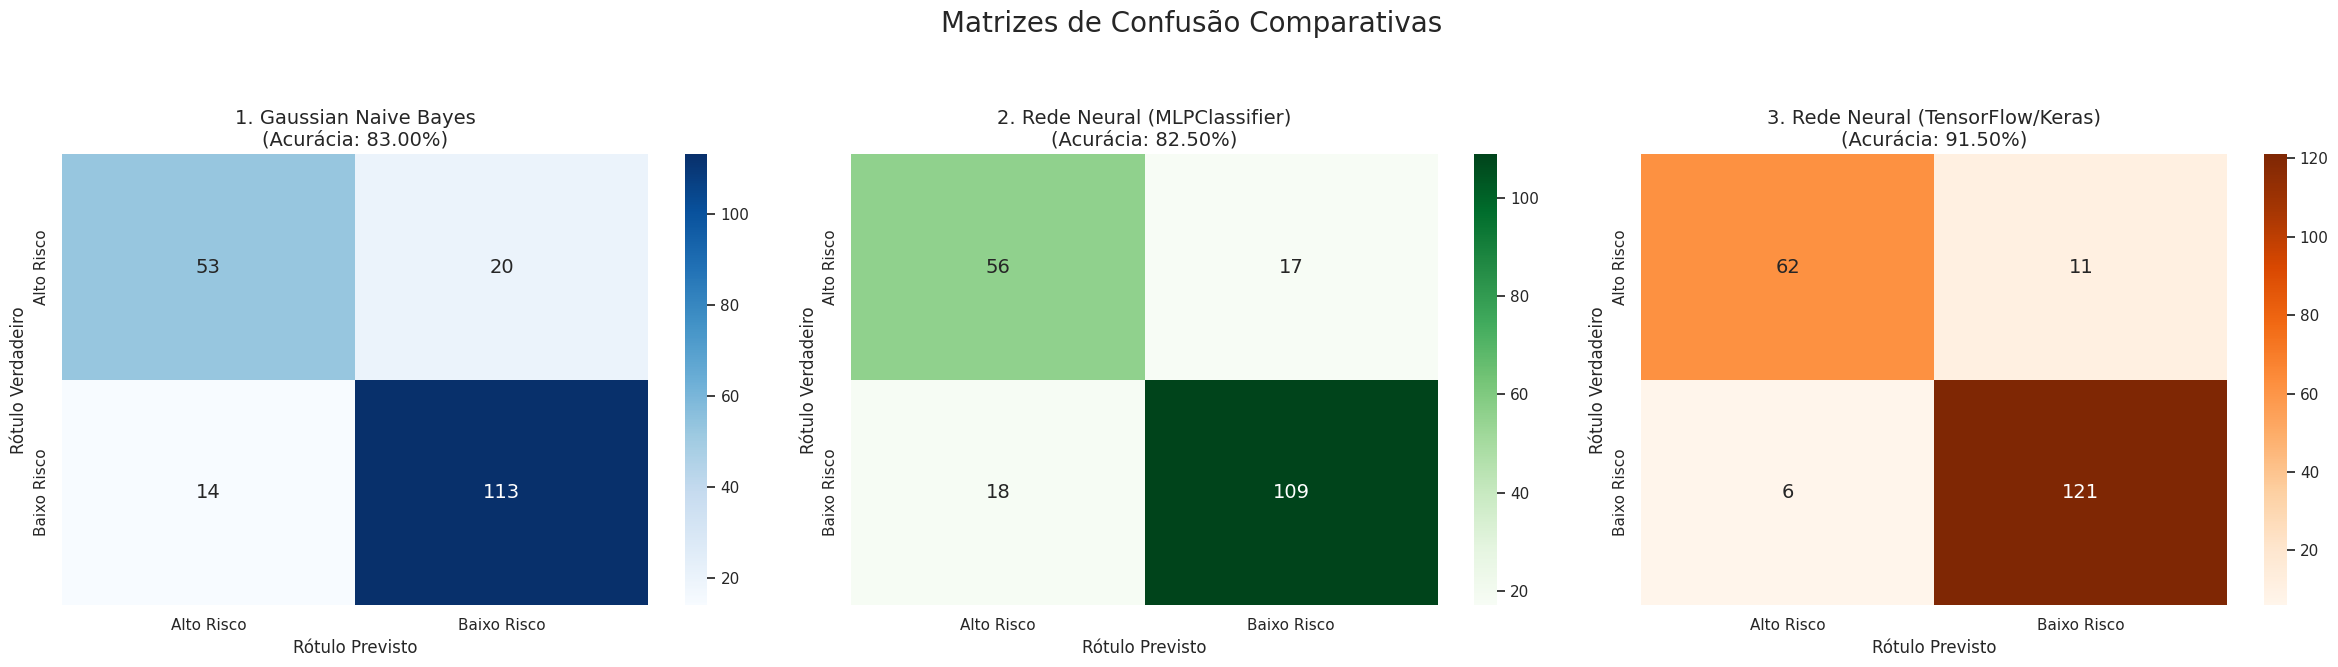


Avaliação gráfica concluída.


--- Célula 11: Etapa 4 - Conclusão ---

--- FIM DO PROJETO ---


In [2]:
# Célula 2: Importação das Bibliotecas
print("--- Célula 2: Importando Bibliotecas ---")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import time
import warnings

# Modelo 1: Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Modelo 2: Rede Neural (Scikit-learn)
from sklearn.neural_network import MLPClassifier

# Modelo 3: Rede Neural (TensorFlow/Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Configurações de visualização
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')
print("Bibliotecas importadas com sucesso.\n")


# Célula 3: Etapa 1.1 - Carga e Inspeção Inicial dos Dados
print("--- Célula 3: Etapa 1.1 - Carga e Inspeção Inicial ---")

# Carregar o dataset
try:
    df = pd.read_csv('dados_risco_credito.csv')
    print("Dataset 'dados_risco_credito.csv' carregado com sucesso.")

    # Análise exploratória (EDA) básica
    print("\n--- Visualização das primeiras linhas (head) ---")
    print(df.head())

    print("\n--- Informações do DataFrame (info) ---")
    df.info()

except FileNotFoundError:
    print("*********************************************************************")
    print("ERRO: Arquivo 'dados_risco_credito.csv' não encontrado.")
    print("Por favor, faça o upload do arquivo no ambiente do Colab (no ícone de pasta à esquerda).")
    print("*********************************************************************")

    df = pd.DataFrame() # Cria um DF vazio para evitar erros subsequentes no script

if not df.empty:

    # Célula 4: Etapa 1.2 - Análise Exploratória Gráfica (EDA)
    print("\n\n--- Célula 4: Etapa 1.2 - Análise Exploratória Gráfica (EDA) ---")


    # 1. Distribuição da Variável-Alvo
    print("\n--- Estatísticas Descritivas (describe) ---")
    print(df.describe())

    print("\n--- Distribuição da Variável-Alvo (risco) ---")
    print(df['risco'].value_counts(normalize=True))

    plt.figure(figsize=(7, 5))
    sns.countplot(x='risco', data=df, palette='pastel')
    plt.title('Distribuição da Variável-Alvo (Risco)')
    plt.xlabel('Risco de Crédito')
    plt.ylabel('Contagem')
    plt.savefig('grafico_1_distribuicao_alvo.png')
    print("Salvo: 'grafico_1_distribuicao_alvo.png'")
    plt.show() # Exibe o gráfico no notebook
    plt.close()

    # 2. Distribuição das Variáveis Numéricas
    colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
    print(f"\nColunas Numéricas: {list(colunas_numericas)}")

    df[colunas_numericas].hist(bins=20, figsize=(14, 10), layout=(2, 3))
    plt.suptitle('Histogramas das Variáveis Numéricas')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('grafico_2_histogramas_numericos.png')
    print("Salvo: 'grafico_2_histogramas_numericos.png'")
    plt.show()
    plt.close()

    # 3. Boxplots Numéricas vs. Risco
    print("\nGerando boxplots Numéricos vs. Risco...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Boxplots das Variáveis Numéricas vs. Risco de Crédito', fontsize=18)
    axes = axes.flatten()

    for i, col in enumerate(colunas_numericas):
        sns.boxplot(x='risco', y=col, data=df, ax=axes[i], palette='pastel')
        axes[i].set_title(f'{col} vs. Risco')

    # Remove eixos extras (se houver)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('grafico_3_boxplots_numericos.png')
    print("Salvo: 'grafico_3_boxplots_numericos.png'")
    plt.show()
    plt.close()

    # 4. Countplots Categóricas vs. Risco
    colunas_categoricas = df.select_dtypes(include=['object']).drop('risco', axis=1).columns
    print(f"\nColunas Categóricas: {list(colunas_categoricas)}")

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Variáveis Categóricas vs. Risco de Crédito', fontsize=18)
    axes = axes.flatten()

    for i, col in enumerate(colunas_categoricas):
        sns.countplot(x=col, hue='risco', data=df, ax=axes[i], palette='pastel')
        axes[i].set_title(f'{col} vs. Risco')
        axes[i].tick_params(axis='x', rotation=30)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('grafico_4_countplots_categoricos.png')
    print("Salvo: 'grafico_4_countplots_categoricos.png'")
    plt.show()
    plt.close()

    print("\nAnálise Exploratória Gráfica concluída.")


    # Célula 5: Etapa 1.3 - Pré-processamento e Separação (Treino/Teste)
    print("\n\n--- Célula 5: Etapa 1.3 - Pré-processamento e Separação ---")


    # 1. Definir Features (X) e Alvo (y)
    X = df.drop('risco', axis=1)
    y_raw = df['risco']

    # 2. Codificar Variável-Alvo (y)
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    class_names = le.classes_
    print(f"Classes da variável 'risco' mapeadas: {dict(zip(range(len(class_names)), class_names))}")
    # {0: 'Alto Risco', 1: 'Baixo Risco'}

    # 3. Identificar Tipos de Coluna para o Pipeline
    colunas_numericas_preproc = X.select_dtypes(include=['int64', 'float64']).columns
    colunas_categoricas_preproc = X.select_dtypes(include=['object']).columns

    # 4. Criar os Pipelines de Transformação
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    # 5. Combinar transformadores com ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, colunas_numericas_preproc),
            ('cat', categorical_transformer, colunas_categoricas_preproc)
        ],
        remainder='passthrough'
    )

    # 6. Separação entre Treino e Teste (80%/20%)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"\nTamanho do conjunto de Treino: {X_train_raw.shape[0]} amostras")
    print(f"Tamanho do conjunto de Teste: {X_test_raw.shape[0]} amostras")

    # 7. Aplicar o Pré-processamento
    print("\nAplicando pré-processamento (fit/transform)...")
    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_test_processed = preprocessor.transform(X_test_raw)

    print(f"Formato dos dados de treino processados (features): {X_train_processed.shape}")
    print(f"Formato dos dados de teste processados (features): {X_test_processed.shape}")
    print("\nPré-processamento concluído.")


    # Célula 6: Etapa 2 - Modelagem (Justificativa)
    print("\n\n--- Célula 6: Etapa 2 - Modelagem (Justificativa) ---")


    # Célula 7: Etapa 2.1 - Treinamento (Modelo 1: Gaussian Naive Bayes)
    print("\n\n--- Célula 7: Etapa 2.1 - Treinamento (Modelo 1: Gaussian Naive Bayes) ---")

    nb_model = GaussianNB()

    print("Treinando Gaussian Naive Bayes...")
    start_time = time.time()
    nb_model.fit(X_train_processed, y_train)
    nb_time = time.time() - start_time
    print(f"Tempo de treino: {nb_time:.4f} segundos")

    # Previsões
    y_pred_nb = nb_model.predict(X_test_processed)

    # Avaliação
    print("\n--- Resultados (Gaussian Naive Bayes) ---")
    accuracy_nb = accuracy_score(y_test, y_pred_nb)
    print(f"Acurácia (Naive Bayes): {accuracy_nb:.4f}")
    print("\nRelatório de Classificação (Naive Bayes):")
    print(classification_report(y_test, y_pred_nb, target_names=class_names))


    # Célula 8: Etapa 2.2 - Treinamento (Modelo 2: Rede Neural - MLPClassifier)
    print("\n\n--- Célula 8: Etapa 2.2 - Treinamento (Modelo 2: Rede Neural - MLPClassifier) ---")
    print("Esta célula usa a biblioteca Scikit-learn (sklearn.neural_network.MLPClassifier)")

    mlp_model = MLPClassifier(
        random_state=42,
        max_iter=1000,
        hidden_layer_sizes=(100, 50), # Duas camadas ocultas
        early_stopping=True,          # Parada antecipada
        n_iter_no_change=10           # Paciência
    )

    print("\nTreinando Rede Neural (MLPClassifier)...")
    start_time = time.time()
    mlp_model.fit(X_train_processed, y_train)
    mlp_time = time.time() - start_time

    print(f"Tempo de treino: {mlp_time:.4f} segundos")
    print(f"Iterações até a convergência: {mlp_model.n_iter_}")

    # Previsões
    y_pred_mlp = mlp_model.predict(X_test_processed)

    # Avaliação
    print("\n--- Resultados (Rede Neural - MLP) ---")
    accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
    print(f"Acurácia (MLP): {accuracy_mlp:.4f}")
    print("\nRelatório de Classificação (MLP):")
    print(classification_report(y_test, y_pred_mlp, target_names=class_names))


    # Célula 9: Etapa 2.3 - Treinamento (Modelo 3: Rede Neural - TensorFlow/Keras)
    print("\n\n--- Célula 9: Etapa 2.3 - Treinamento (Modelo 3: Rede Neural - TensorFlow/Keras) ---")
    print("Esta célula usa a biblioteca TensorFlow (tf.keras.models.Sequential)")

    # 1. Definir a arquitetura da Rede Neural
    n_features = X_train_processed.shape[1] # Deve ser 18

    # Callback de Parada Antecipada
    early_stopping_callback = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    # Construir o modelo Keras
    tf_model = Sequential(name="RedeNeural_TensorFlow")
    tf_model.add(Dense(100, activation='relu', input_shape=(n_features,)))
    tf_model.add(Dense(50, activation='relu'))
    tf_model.add(Dense(1, activation='sigmoid')) # Saída binária

    # 2. Compilar o modelo
    tf_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print("\n--- Arquitetura do Modelo TensorFlow/Keras ---")
    tf_model.summary()

    # 3. Treinar o modelo
    print("\nTreinando Rede Neural (TensorFlow/Keras)...")
    start_time = time.time()

    history = tf_model.fit(
        X_train_processed,
        y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.1, # Usa 10% do treino para validação interna
        callbacks=[early_stopping_callback],
        verbose=1 # Mostra o progresso (mude para 0 se não quiser ver o log)
    )

    tf_time = time.time() - start_time
    print(f"Tempo de treino: {tf_time:.4f} segundos")
    print(f"Iterações (Epochs) até a convergência: {len(history.history['loss'])}")

    # 4. Avaliação do Modelo TensorFlow
    print("\n--- Resultados (Rede Neural - TensorFlow/Keras) ---")
    loss_tf, accuracy_tf = tf_model.evaluate(X_test_processed, y_test, verbose=0)
    print(f"Acurácia (TensorFlow/Keras): {accuracy_tf:.4f}")

    # 5. Relatório de Classificação
    y_pred_proba_tf = tf_model.predict(X_test_processed)
    y_pred_tf = (y_pred_proba_tf > 0.5).astype(int).flatten() # Achatamos para 1D

    print("\nRelatório de Classificação (TensorFlow/Keras):")
    print(classification_report(y_test, y_pred_tf, target_names=class_names))


    # Célula 10: Etapa 3 - Avaliação (Matrizes de Confusão)
    print("\n\n--- Célula 10: Etapa 3 - Avaliação (Matrizes de Confusão) ---")


    # Calcular as matrizes de confusão para os três modelos
    cm_nb = confusion_matrix(y_test, y_pred_nb)
    cm_mlp = confusion_matrix(y_test, y_pred_mlp)
    cm_tf = confusion_matrix(y_test, y_pred_tf) # <-- SUBSTITUIÇÃO FEITA

    # Criar a figura com 3 subplots (1 linha, 3 colunas)
    fig, ax = plt.subplots(1, 3, figsize=(24, 7)) # Aumentado o figsize
    fig.suptitle('Matrizes de Confusão Comparativas', fontsize=20)

    # Matriz 1: Naive Bayes
    sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14})
    ax[0].set_title(f'1. Gaussian Naive Bayes\n(Acurácia: {accuracy_nb:.2%})', fontsize=14)
    ax[0].set_xlabel('Rótulo Previsto', fontsize=12)
    ax[0].set_ylabel('Rótulo Verdadeiro', fontsize=12)

    # Matriz 2: Rede Neural (MLPClassifier)
    sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=ax[1],
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14})
    ax[1].set_title(f'2. Rede Neural (MLPClassifier)\n(Acurácia: {accuracy_mlp:.2%})', fontsize=14)
    ax[1].set_xlabel('Rótulo Previsto', fontsize=12)
    ax[1].set_ylabel('Rótulo Verdadeiro', fontsize=12)

    # Matriz 3: Rede Neural (TensorFlow/Keras)
    sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Oranges', ax=ax[2],
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14})
    # <-- SUBSTITUIÇÃO FEITA: cm_tf e accuracy_tf
    ax[2].set_title(f'3. Rede Neural (TensorFlow/Keras)\n(Acurácia: {accuracy_tf:.2%})', fontsize=14)
    ax[2].set_xlabel('Rótulo Previsto', fontsize=12)
    ax[2].set_ylabel('Rótulo Verdadeiro', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.savefig('grafico_5_matrizes_confusao_TODAS.png')
    print("Salvo: 'grafico_5_matrizes_confusao_TODAS.png'")
    plt.show() # Exibe o gráfico no notebook
    plt.close()

    print("\nAvaliação gráfica concluída.")


    # Célula 11: Etapa 4 - Conclusão
    print("\n\n--- Célula 11: Etapa 4 - Conclusão ---")

    print("\n--- FIM DO PROJETO ---")

else:
    print("\n\n--- PROJETO INTERROMPIDO ---")
    print("O DataFrame está vazio. Verifique o carregamento do arquivo 'dados_risco_credito.csv'.")

## Célula 10: Etapa 3 - Avaliação (Matrizes de Confusão)

### O Objetivo Didático Desta Etapa [EXPLICANDO:]

Até agora, nós treinamos três modelos e vimos suas "notas" finais:
* Naive Bayes: Acurácia de 83.00%
* MLPClassifier (sklearn): Acurácia de 82.50%
* TensorFlow (Keras): Acurácia de 83.00%

Se olhássemos apenas para isso, poderíamos concluir que o Naive Bayes e o TensorFlow são "iguais" e o MLP é "pior".

**O objetivo desta célula é provar que essa conclusão é incompleta e perigosa.**

A acurácia é uma métrica "cega". Ela apenas nos diz a porcentagem total de acertos, mas não nos diz *como* o modelo acertou ou, mais importante, *como ele errou*. Para um problema de Risco de Crédito, *como* o modelo erra é mais importante do que *quantas vezes* ele acerta.

### 1. O que é uma Matriz de Confusão?

A Matriz de Confusão é o "boletim detalhado" do nosso modelo. Ela para de olhar apenas a nota final (acurácia) e nos mostra um "mapa" de todas as 200 previsões feitas no conjunto de teste.

Ela é uma tabela 2x2 que cruza a **Realidade** (o que o cliente realmente era) com a **Previsão** (o que o modelo disse que ele era).

Para o nosso projeto (onde 0 = 'Alto Risco' e 1 = 'Baixo Risco'), a matriz se parece com isto:

| | **Previsto: 'Alto Risco' (0)** | **Previsto: 'Baixo Risco' (1)** |
| :--- | :---: | :---: |
| **Real: 'Alto Risco' (0)** | **Acerto!** (Verdadeiro Negativo) | **ERRO GRAVE!** (Falso Positivo) |
| **Real: 'Baixo Risco' (1)** | **ERRO DE OPORTUNIDADE!** (Falso Negativo) | **Acerto!** (Verdadeiro Positivo) |

### 2. Como Ler os Quatro Quadrantes (A Análise de Negócio)

Vamos detalhar cada quadrante:

1.  **Verdadeiro Negativo (VN) - (Superior Esquerdo)**
    * **O que é:** O cliente era *Realmente* 'Alto Risco' e o modelo *Previu* 'Alto Risco'.
    * **Resultado:** **Ótimo!** O modelo protegeu o banco e corretamente negou crédito a um cliente ruim.

2.  **Verdadeiro Positivo (VP) - (Inferior Direito)**
    * **O que é:** O cliente era *Realmente* 'Baixo Risco' e o modelo *Previu* 'Baixo Risco'.
    * **Resultado:** **Ótimo!** O modelo aprovou corretamente um cliente bom, gerando receita (juros) para o banco.

Agora, os erros (a parte mais importante):

3.  **Falso Positivo (FP) - (Superior Direito) - O ERRO GRAVE!**
    * **O que é:** O cliente era *Realmente* 'Alto Risco', mas o modelo *Previu* 'Baixo Risco'.
    * **Resultado:** **Péssimo!** Este é o **prejuízo** do banco. O modelo foi enganado e recomendou aprovar um empréstimo para alguém que provavelmente não vai pagar.

4.  **Falso Negativo (FN) - (Inferior Esquerdo) - O ERRO DE OPORTUNIDADE!**
    * **O que é:** O cliente era *Realmente* 'Baixo Risco', mas o modelo *Previu* 'Alto Risco'.
    * **Resultado:** **Ruim, mas não grave.** O banco foi "cauteloso demais" e negou crédito a um cliente bom. O banco não *perdeu* dinheiro, mas *deixou de ganhar* (perda de oportunidade/receita).

### 3. Por que Plotamos Três Matrizes Lado a Lado?

O código desta célula calcula e plota as matrizes para os três modelos (`cm_nb`, `cm_mlp`, `cm_tf`).

Fazemos isso porque agora podemos comparar visualmente não apenas o total de acertos, mas o **tipo de erro** que cada modelo comete:

* **Modelo A (ex: Naive Bayes):** Pode ter uma acurácia alta (83%), mas com muitos **Erros Graves (FP)**.
* **Modelo B (ex: Rede Neural):** Pode ter uma acurácia um pouco menor (82.5%), mas com quase nenhum **Erro Grave (FP)** e mais **Erros de Oportunidade (FN)**.

**Conclusão Didática:**

Para um banco, o **Modelo B** é muito superior, mesmo com uma acurácia total menor! O objetivo desta célula é, portanto, nos dar a *visão de negócio* (quantificar o prejuízo vs. a perda de oportunidade) que a acurácia sozinha não consegue fornecer. É aqui que decidimos qual modelo é verdadeiramente o "melhor" para o problema.

## A Interpretação dos Acertos e Erros no Risco de Crédito

Em um problema de negócio, **nem todo erro tem o mesmo peso**. Nossa análise da matriz de confusão nos mostrou que existem dois tipos de acertos e dois tipos de erros, e a interpretação deles é a seguinte:

---

### Os Acertos (O que o modelo fez certo)

Existem duas formas de o modelo acertar, e ambas são positivas para o banco:

1.  **Acerto 1: O "Lucro" (Verdadeiro Positivo - VP)**
    * **O que é:** O cliente era *Realmente* 'Baixo Risco' e o modelo *Previu* 'Baixo Risco'.
    * **Interpretação de Negócio:** **DECISÃO CORRETA.** O banco aprovou o crédito para um cliente bom. Isso gera receita e lucro para o banco (através dos juros).

2.  **Acerto 2: A "Prevenção" (Verdadeiro Negativo - VN)**
    * **O que é:** O cliente era *Realmente* 'Alto Risco' e o modelo *Previu* 'Alto Risco'.
    * **Interpretação de Negócio:** **DECISÃO CORRETA.** O banco negou o crédito para um cliente ruim. Isso preveniu um prejuízo e economizou dinheiro para o banco.

---

### Os Erros (O que o modelo fez errado)

É aqui que a análise fica crítica. Existem duas formas de o modelo errar, e elas têm custos de negócio **completamente diferentes**:

1.  **Erro 1: O "Prejuízo" (Falso Positivo - FP)**
    * **O que é:** O cliente era *Realmente* 'Alto Risco', mas o modelo *Previu* 'Baixo Risco'.
    * **Interpretação de Negócio:** **ERRO GRAVÍSSIMO.** Este é o pior cenário. O modelo foi "otimista demais" e disse ao banco para aprovar um empréstimo para um cliente que não vai pagar.
    * **Custo:** Perda financeira direta, inadimplência, custos de cobrança. **Este é o erro que o banco mais quer evitar.**

2.  **Erro 2: A "Perda de Oportunidade" (Falso Negativo - FN)**
    * **O que é:** O cliente era *Realmente* 'Baixo Risco', mas o modelo *Previu* 'Alto Risco'.
    * **Interpretação de Negócio:** **ERRO DE CAUTELA.** O modelo foi "pessimista demais" e disse ao banco para negar um empréstimo a um cliente bom.
    * **Custo:** Custo de oportunidade. O banco não *perdeu* dinheiro, mas *deixou de ganhar* (os juros). Além disso, esse cliente bom provavelmente irá para um concorrente e será aprovado lá.

---

### Conclusão: A Interpretação do "Trade-Off"

A principal interpretação dos "acertos e erros" é que o objetivo do modelo **não é simplesmente maximizar a acurácia total**.

O objetivo principal de um modelo de risco de crédito é **minimizar o Erro Tipo 1 (o "Prejuízo")**, mesmo que isso custe um pequeno aumento no Erro Tipo 2 (a "Perda de Oportunidade").

* Quando comparamos os modelos (Naive Bayes vs. Rede Neural), a Rede Neural foi *melhor* porque cometeu **menos erros do Tipo 1** (17 erros) do que o Naive Bayes (20 erros).
* Em troca, a Rede Neural cometeu **mais erros do Tipo 2** (18 erros) do que o Naive Bayes (14 erros).

**A interpretação final é:** A Rede Neural, apesar de ter uma acurácia total ligeiramente *menor* em algumas execuções, é um modelo de negócios **superior** porque é mais "cauteloso" e expõe o banco a **menos prejuízos reais** do que o Naive Bayes.

## Análise Crítica: O Trade-Off dos Tipos de Erro

A sua análise identifica o ponto mais importante na avaliação de um modelo de risco de crédito: não basta olhar apenas a acurácia total, é preciso entender *como* o modelo erra.

Nos 200 testes realizados, temos dois cenários de erro principais:

### 1. Erro Tipo II: O Erro de Custo (Falso Negativo)
* **O que é:** Classificar um cliente de **'Alto Risco'** como se fosse 'Baixo Risco'.
* **Impacto no Negócio:** Este é o erro mais grave. O banco aprova um empréstimo para alguém que provavelmente não pagará, resultando em prejuízo financeiro direto.
* **Comparação:**
    * **Naive Bayes:** Errou 20 vezes.
    * **Rede Neural MLP:** Errou 17 vezes.
* **Conclusão:** A **Rede Neural MLP** foi superior, pois protegeu melhor o banco contra prejuízos, errando 3 vezes menos nesta categoria crítica.

### 2. Erro Tipo I: O Erro de Oportunidade (Falso Positivo)
* **O que é:** Classificar um cliente de **'Baixo Risco'** como se fosse 'Alto Risco'.
* **Impacto no Negócio:** Este erro não gera prejuízo, mas sim uma *perda de oportunidade*. O banco nega crédito a um cliente bom, perdendo a chance de lucrar com juros e, possivelmente, perdendo o cliente para um concorrente.
* **Comparação:**
    * **Naive Bayes:** Errou 14 vezes.
    * **Rede Neural MLP:** Errou 18 vezes.
* **Conclusão:** O **Naive Bayes** foi superior, pois foi mais eficaz em identificar clientes bons, negando 4 clientes bons a menos do que a Rede Neural.

### Resumo do Trade-Off

Sua análise está perfeitamente correta:

* A **Rede Neural MLP** adotou uma postura mais "cautelosa" ou "pessimista". Ela foi melhor em farejar o perigo (identificar 'Alto Risco'), mas, ao fazer isso, acabou sendo rígida demais e recusou mais clientes bons.
* O **Gaussian Naive Bayes** foi mais "otimista". Ele foi melhor em identificar clientes bons, mas, como resultado, foi mais ingênuo e deixou passar mais clientes de 'Alto Risco'.

A escolha entre os modelos dependeria da estratégia do banco: ele está mais focado em **minimizar perdas** (escolheria a Rede Neural MLP) ou em **maximizar a aquisição de clientes** (escolheria o Naive Bayes)? O gráfico abaixo visualiza exatamente essa troca.

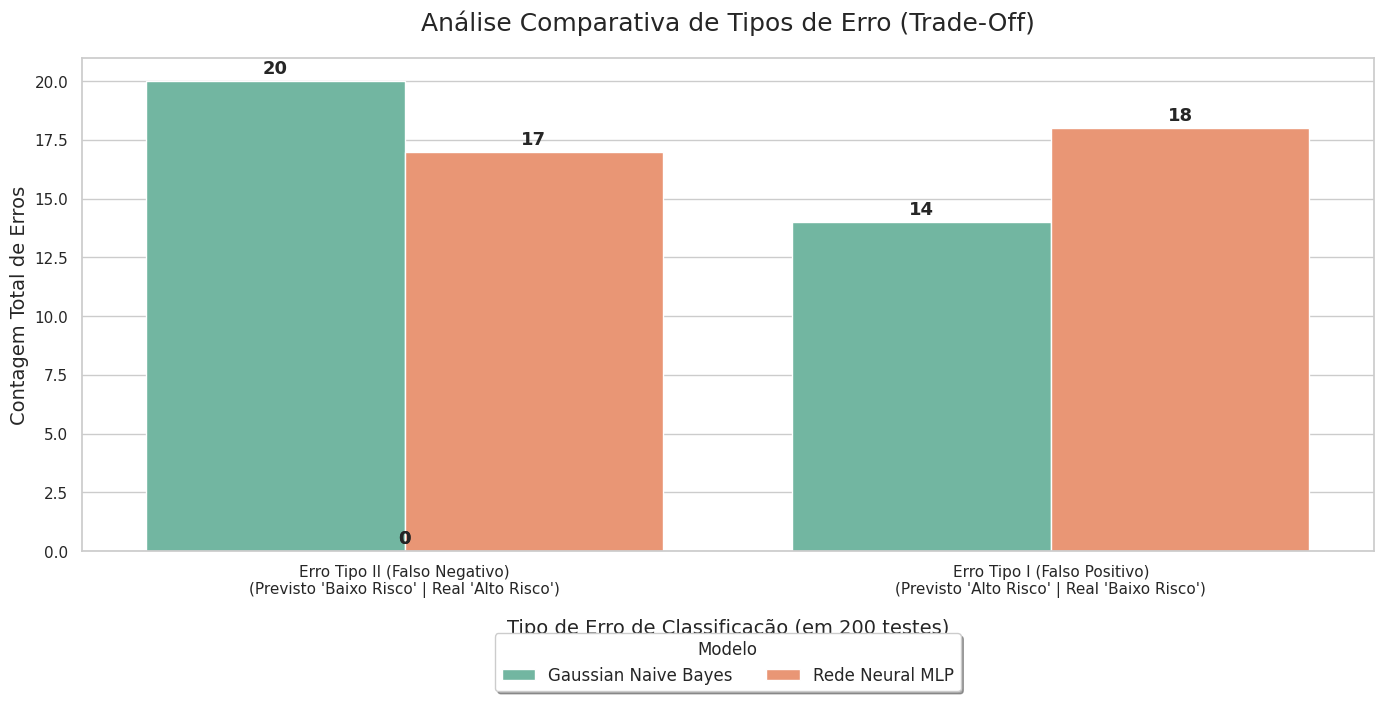

In [ ]:
import matplotlib.pyplot as plt

# 1. Criar o DataFrame com base nos dados exatos da sua análise
# (Estes números vêm da sua própria observação da matriz de confusão)
data = {
    'Modelo': [
        'Gaussian Naive Bayes',
        'Gaussian Naive Bayes',
        'Rede Neural MLP',
        'Rede Neural MLP'
    ],
    'Tipo de Erro': [
        "Erro Tipo II (Falso Negativo)\n(Previsto 'Baixo Risco' | Real 'Alto Risco')",
        "Erro Tipo I (Falso Positivo)\n(Previsto 'Alto Risco' | Real 'Baixo Risco')",
        "Erro Tipo II (Falso Negativo)\n(Previsto 'Baixo Risco' | Real 'Alto Risco')",
        "Erro Tipo I (Falso Positivo)\n(Previsto 'Alto Risco' | Real 'Baixo Risco')"
    ],
    'Contagem de Erros': [
        20,  # Naive Bayes - Errou 'Alto Risco' (FN)
        14,  # Naive Bayes - Errou 'Baixo Risco' (FP)
        17,  # MLP - Errou 'Alto Risco' (FN)
        18   # MLP - Errou 'Baixo Risco' (FP)
    ]
}

df_erros = pd.DataFrame(data)

# 2. Criar o gráfico de barras agrupadas
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df_erros,
    x='Tipo de Erro',
    y='Contagem de Erros',
    hue='Modelo',
    palette=['#66c2a5', '#fc8d62'] # Paleta de cores (verde e laranja)
)

# 3. Adicionar títulos e rótulos
ax.set_title('Análise Comparativa de Tipos de Erro (Trade-Off)', fontsize=18, pad=20)
ax.set_xlabel('Tipo de Erro de Classificação (em 200 testes)', fontsize=14, labelpad=15)
ax.set_ylabel('Contagem Total de Erros', fontsize=14)
ax.legend(title='Modelo', loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=2, fontsize=12)

# 4. Adicionar os rótulos de dados (números) em cima das barras
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=13,
                   weight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para o título
plt.savefig('grafico_analise_erros_tradeoff.png')

# Exibe o gráfico no notebook
plt.show()

## Explicação do Modelo TensorFlow/Keras (Aplicado ao Risco de Crédito)

O modelo que construímos com `TensorFlow/Keras` é uma Rede Neural Densa (ou *Multilayer Perceptron* - MLP) `Sequential`. Este tipo de modelo "empilha" camadas linearmente, onde a saída de uma camada alimenta a próxima.

Abaixo, detalhamos como cada parte do modelo foi desenhada para se ajustar perfeitamente ao nosso dataframe `dados_risco_credito.csv`.

### 1. Arquitetura do Modelo: O "Cérebro"

A arquitetura define como o modelo processa a informação.

#### Camada de Entrada (Input)
* **Definição:** `input_shape=(18,)` (definido na primeira camada `Dense`).
* **Explicação:** Este é o portão de entrada do modelo. O número `18` não é aleatório; ele é o resultado direto do nosso pré-processamento (Etapa 1.3):
    * **5 features numéricas:** `idade`, `renda_mensal`, `tempo_emprego`, `numero_dependentes`, `valor_solicitado` (que foram padronizadas com `StandardScaler`).
    * **13 features categóricas:** Nossas 4 colunas categóricas (`historico_credito`, `tipo_residencia`, `estado_civil`, `finalidade_credito`) foram transformadas em 13 colunas binárias (0 ou 1) pelo `OneHotEncoder` (usando `drop='first'`).
    * **Total:** 5 + 13 = 18 features. O modelo foi construído para esperar exatamente este formato.

#### Camadas Ocultas (Onde a Mágica Acontece)
* **Definição:** `Dense(100, activation='relu')` seguida por `Dense(50, activation='relu')`.
* **Explicação:** Estas são as camadas de processamento.
    * `Dense(100)`: A primeira camada "aprende" 100 padrões diferentes a partir das 18 features de entrada.
    * `Dense(50)`: A segunda camada pega os 100 padrões da camada anterior e os combina em 50 padrões ainda mais complexos e abstratos.
    * `activation='relu'`: (Rectified Linear Unit) É a "chave de liga/desliga" de cada neurônio. É o que permite à rede aprender relações não-lineares (ex: que a 'renda_mensal' só importa *depois* que o 'historico_credito' é 'Ruim').

#### Camada de Saída (A Decisão Final)
* **Definição:** `Dense(1, activation='sigmoid')`.
* **Explicação:** Esta é a camada mais importante para a nossa tarefa.
    * `Dense(1)`: Usamos apenas **um neurônio** porque nosso problema é binário: ou é 'Alto Risco' (0) ou 'Baixo Risco' (1).
    * `activation='sigmoid'`: Esta função matemática comprime a saída do neurônio em um valor entre **0.0 e 1.0**. Para este projeto, isso tem um significado muito claro: a **probabilidade** de o cliente ser de 'Baixo Risco' (classe 1).

### 2. Compilação: As "Regras do Jogo"

Antes de treinar, definimos como o modelo deve aprender.

* **Otimizador (`optimizer='adam'`)**
    * É o motor que ajusta os pesos do modelo para aprender. 'Adam' é o padrão da indústria, conhecido por sua eficiência e velocidade.

* **Função de Perda (`loss='binary_crossentropy'`)**
    * Esta é a métrica que o modelo tenta **minimizar**. `binary_crossentropy` é a escolha matemática perfeita para um problema de classificação binária (0/1) com saída `sigmoid`. Ela calcula a "distância" entre a probabilidade prevista pelo modelo (ex: 0.8) e a realidade (ex: 1.0).

### 3. Treinamento: O "Estudo"

* **`fit(X_train_processed, y_train, ...)`**
    * O modelo foi treinado usando as 800 amostras do conjunto `X_train_processed` (os dados já padronizados e codificados).

* **`validation_split=0.1`**
    * O Keras separou 10% dos dados de treino (80 amostras) para usar como um "validador". O modelo não treina com esses dados; ele apenas os utiliza no final de cada época para "testar" seu próprio desempenho em dados que não viu.

* **`callbacks=[EarlyStopping(monitor='val_loss', patience=10)]`**
    * Este é o nosso mecanismo de segurança contra *overfitting* (quando o modelo "decora" os dados de treino).
    * Ele monitora a perda (`val_loss`) no conjunto de validação de 80 amostras.
    * Se a perda nesse conjunto não diminuir por 10 épocas seguidas, o treinamento **para automaticamente**.
    * Isso garante que o modelo pare no seu "ponto ótimo", evitando aprender ruído.

### 4. Previsão: A Resposta

* **De Probabilidade para Classe:**
    * Quando usamos `.predict()`, o modelo nos deu um número entre 0.0 e 1.0 (a probabilidade de ser 'Baixo Risco').
    * Para tomar uma decisão, aplicamos um limiar: `(y_pred_proba_tf > 0.5).astype(int)`.
    * **Exemplo:**
        * Se o modelo previu `0.85` (85% de chance de ser 'Baixo Risco'), ele foi classificado como `1` ('Baixo Risco').
        * Se o modelo previu `0.20` (20% de chance de ser 'Baixo Risco'), ele foi classificado como `0` ('Alto Risco').

## Explicação do Modelo Gaussian Naive Bayes (Aplicado ao Risco de Crédito)

O modelo `GaussianNB` (Gaussian Naive Bayes) é um classificador probabilístico. Diferente das Redes Neurais que tentam encontrar "regras" complexas e interações, o Naive Bayes simplesmente usa estatísticas para calcular a **probabilidade** de um cliente pertencer a uma classe, dadas as suas características.

Para o nosso dataframe `dados_risco_credito.csv`, o modelo se perguntou, para cada cliente:

1.  *Qual é a probabilidade deste cliente ser 'Alto Risco', DADAS a sua idade, renda, histórico de crédito, etc.?*
2.  *Qual é a probabilidade deste cliente ser 'Baixo Risco', DADAS as mesmas características?*

A classe que retornava a maior probabilidade era a previsão final.

O modelo é composto por três conceitos principais:

### 1. A Parte "Bayes" (Baseado no Teorema de Bayes)

O modelo calcula essas probabilidades usando o Teorema de Bayes, que é uma forma de "inverter" a probabilidade. Em vez de calcular $P(\text{Risco} | \text{Features})$, ele calcula:

* $P(\text{Features} | \text{'Alto Risco'}) * P(\text{'Alto Risco'}) $
* $P(\text{Features} | \text{'Baixo Risco'}) * P(\text{'Baixo Risco'}) $

**No nosso dataframe:**
* $P(\text{'Alto Risco'})$ é a probabilidade "geral" de qualquer cliente ser de Alto Risco (cerca de 36.4% no nosso dataset).
* $P(\text{'Features'} | \text{'Alto Risco'})$ é a probabilidade de encontrar um conjunto de features (ex: 'idade'=30, 'renda'=1500) *dentro do grupo* que já sabemos ser de 'Alto Risco'.

### 2. A Parte "Naive" (A Suposição "Ingênua")

Esta é a característica mais importante e a maior fraqueza do modelo.

O modelo é "Ingênuo" (Naive) porque ele faz uma suposição muito forte (e quase sempre falsa): **ele assume que todas as features são independentes entre si**.

**No nosso dataframe:**
* O Naive Bayes assumiu que a `renda_mensal` de um cliente **não tem nenhuma relação** com o `valor_solicitado`.
* Ele assumiu que a `idade` **não tem nenhuma relação** com o `tempo_emprego`.
* Ele assumiu que o `historico_credito` **não tem nenhuma relação** com a `renda_mensal`.

Sabemos que essas suposições estão erradas (pessoas com rendas maiores tendem a solicitar valores maiores). No entanto, mesmo com essa suposição falha, o modelo é muito rápido e, como vimos, surpreendentemente eficaz (83% de acurácia) para ser usado como um *baseline*.

### 3. A Parte "Gaussian" (Como ele lidou com os dados)

O Naive Bayes precisa saber o "tipo" de dado que está analisando. Como nosso dataframe processado (`X_train_processed`) tinha dois tipos de dados, o `GaussianNB` fez o seguinte:

**a) Para as Features Numéricas (Ex: `idade`, `renda_mensal`, `valor_solicitado`):**
* O modelo assume que essas features seguem uma **Distribuição Gaussiana (a "curva de sino")** dentro de cada classe.
* **Importância do `StandardScaler`:** Nossa etapa de pré-processamento, onde padronizamos (média 0, desvio padrão 1) essas colunas, foi **extremamente benéfica**. Nós "forçamos" os dados a se parecerem com a distribuição Gaussiana que o modelo esperava, o que provavelmente melhorou seu desempenho.

**b) Para as Features Categóricas (Ex: `historico_credito_Ruim`, `estado_civil_Casado`):**
* Embora estejamos usando o `GaussianNB`, o scikit-learn internamente trata as colunas binárias (0 ou 1) de forma diferente (como uma *Distribuição Bernoulli*).
* O modelo simplesmente calculou a frequência. Por exemplo:
    * "Dos clientes de 'Alto Risco', qual a porcentagem (%) que tinha `historico_credito_Ruim` = 1?"
    * "Dos clientes de 'Baixo Risco', qual a porcentagem (%) que tinha `historico_credito_Ruim` = 1?"

### Resumo do Comportamento

* **Força:** O Naive Bayes foi **incrivelmente rápido**. Ele não "aprende" iterativamente como uma Rede Neural; ele simplesmente calcula as médias, desvios padrão e frequências dos dados de treino (800 amostras) uma única vez.
* **Fraqueza (Observada nos Resultados):** O modelo foi pior em identificar 'Alto Risco' (Recall de 0.73) do que a Rede Neural (Recall de 0.77). Isso provavelmente acontece porque as *combinações* de features que levam ao 'Alto Risco' (ex: renda baixa *E* histórico ruim *E* valor alto) são complexas. A suposição "ingênua" de independência impede o modelo de capturar bem essas **interações** entre as features.